Physics-informed symbolic regression workflow for alloy strengthening (PySR)

This script implements a structured symbolic regression pipeline to model
hardness in Pt–Au alloys based on physically motivated strengthening mechanisms.

Workflow:
1. Load and clean experimental data (grain size, solute distribution, dislocation density).
2. Train three mechanism-specific symbolic models using template constraints:
   (i) Hall–Petch strengthening (grain size),
   (ii) solid-solution strengthening (solute in grain and grain boundaries),
   (iii) dislocation strengthening (dislocation density).
3. Evaluate each model using R², MAE, and MSE, and generate predictions.
4. Combine the predicted contributions from all mechanisms and train a unified
   symbolic regression model to capture overall hardness.
5. Output final expressions, performance metrics, and optional prediction tables.

Notes:
- All models are trained using PySR with physics-guided templates to ensure interpretability.

Author: Quan li; quan.li@mpi-susmat.de

In [ ]:
import os
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pysr import PySRRegressor, TemplateExpressionSpec
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ============================================================
# 0. User settings 
# ============================================================
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # Fallback for Jupyter / interactive environments
    PROJECT_ROOT = Path.cwd()

FILE_PATH = PROJECT_ROOT / "data" / "Dataset_PtAu.xlsx"
SHEET_NAME = "Anneal_Punch"

SAVE_RESULTS = True
OUTPUT_ROOT = PROJECT_ROOT / "results"

NPROCS = 6

# Check dataset
if not FILE_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {FILE_PATH}\n"
        "Please place the dataset in the 'data/' directory."
    )

print(f"Using dataset: {FILE_PATH}")

In [2]:
# ============================================================
# 1. Utility functions
# ============================================================
def print_metrics(y_true, y_pred, model_name="Model"):
    """Print regression metrics."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    print(f"\n[{model_name}] Performance")
    print(f"R²  = {r2:.4f}")
    print(f"MAE = {mae:.4f}")
    print(f"MSE = {mse:.4f}")

    return {"R2": r2, "MAE": mae, "MSE": mse}


def fit_and_evaluate_model(
    model,
    X,
    y,
    model_name="Model"
):
    """
    Fit a PySR model, predict on the same dataset, and report metrics.
    """
    model.fit(X, y)

    print(f"\nBest expression of [{model_name}]")
    print(model.get_best())

    y_pred = model.predict(X)
    metrics = print_metrics(y, y_pred, model_name=model_name)

    return model, y_pred, metrics


def plot_feature_vs_target(df, feature_cols, target_col, figsize=(15, 8)):
    """Scatter plots of each feature against the target."""
    n_features = len(feature_cols)
    ncols = 3
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    y = df[target_col].values

    for i, col in enumerate(feature_cols):
        axes[i].scatter(df[col].values, y, alpha=0.6)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_col)
        axes[i].set_title(f"{col} vs. {target_col}")
        axes[i].grid(True)

    # Hide unused axes
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


def plot_pred_vs_true(y_true, y_pred, model_name="Model"):
    """Predicted vs. true scatter plot."""
    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.7)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], "--")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"{model_name}: Predicted vs. True")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def ensure_output_dir(path_obj):
    """Create output directory if saving is enabled."""
    path_obj.mkdir(parents=True, exist_ok=True)

In [3]:
# ============================================================
# 2. Load data
# ============================================================
print("1. File path:", FILE_PATH)
file_name = os.path.basename(FILE_PATH)
print("2. File name:", file_name)

xls = pd.ExcelFile(FILE_PATH, engine="openpyxl")
print(f"3. Number of sheets: {len(xls.sheet_names)}")
print("4. Sheet names:", xls.sheet_names)

df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, engine="openpyxl")
print("\nSelected sheet:", SHEET_NAME)
print("Columns:", list(df.columns))

1. File path: D:\Research\PtAu\Manuscript\20260322-Submitted_Nature\20260111-Dataset_PtAu.xlsx
2. File name: 20260111-Dataset_PtAu.xlsx
3. Number of sheets: 1
4. Sheet names: ['Anneal_Punch']

Selected sheet: Anneal_Punch
Columns: ['Data No.', 'anneal', 'punch', 'grain size', 'Au in grain', 'Au at gb', 'Pt in grain', 'Pt at gb', 'dislocation density', 'hardness']



Cleaned data shape: (396, 6)
Retained columns: ['Data No.', 'hardness', 'grain size', 'Au in grain', 'Au at gb', 'dislocation density']


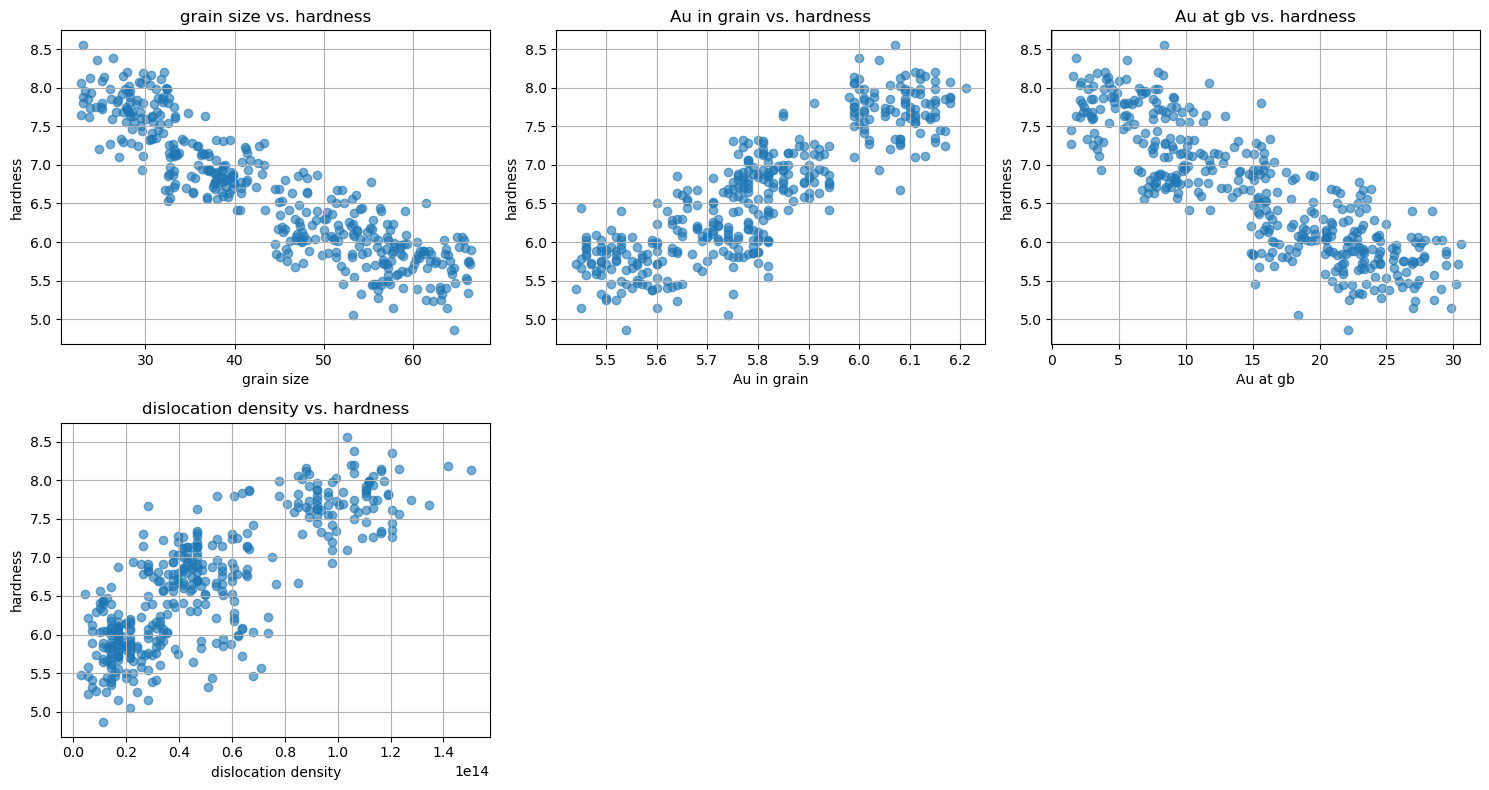

In [16]:
# ============================================================
# 3. Define columns and clean data only once
# ============================================================
target_col = "hardness"
feature_cols_all = [
    "grain size",
    "Au in grain",
    "Au at gb",
    "dislocation density",
]

required_cols = ["Data No.", target_col] + feature_cols_all
data_clean = df[required_cols].dropna().copy()

print("\nCleaned data shape:", data_clean.shape)
print("Retained columns:", required_cols)

# Optional data distribution plots
plot_feature_vs_target(data_clean, feature_cols_all, target_col)


# Full clean target
y_all = data_clean[target_col].values

# Inputs for each mechanism
X_hp = data_clean[["grain size"]].values
X_sss = data_clean[["grain size", "Au in grain", "Au at gb"]].values
X_dis = data_clean[["dislocation density"]].values
X_full = data_clean[feature_cols_all].values  # reserved if needed later

In [17]:
# ============================================================
# 4. Define PySR templates
# ============================================================

# 4.1 Hall-Petch template
template_hp = TemplateExpressionSpec(
    expressions={
        "HP": "a + b * x0^c"
    },
    combine="HP(x0)",
    variable_names=["x0"],
    parameters={p: 1 for p in "abc"},
)

model_hp = PySRRegressor(
    expression_spec=template_hp,
    binary_operators=["+", "-", "*", "^"],
    unary_operators=[],
    constraints={"^": (-1, 1)},
    maxsize=20,
    niterations=1000,
    early_stop_condition="stop_if(loss, complexity) = loss < 0.0905 && complexity < 25",
    model_selection="best",
    elementwise_loss="loss(x, y) = (x - y)^2",
    verbosity=3,
    procs=NPROCS,
    warm_start=True,
    output_directory=str(OUTPUT_ROOT / "HP_result") if SAVE_RESULTS else None,
)

# 4.2 Solid-solution strengthening template
template_sss = TemplateExpressionSpec(
    expressions={
        "SSS": "d * x1^e + f * x2^g * x0^h"
    },
    combine="SSS(x0, x1, x2)",
    variable_names=["x0", "x1", "x2"],
    parameters={p: 1 for p in "defgh"},
)

model_sss = PySRRegressor(
    expression_spec=template_sss,
    binary_operators=["+", "-", "*", "^"],
    unary_operators=[],
    constraints={"^": (-1, 1)},
    maxsize=30,
    niterations=1000,
    early_stop_condition="stop_if(loss, complexity) = loss < 0.08 && complexity < 25",
    model_selection="best",
    elementwise_loss="loss(x, y) = (x - y)^2",
    verbosity=3,
    procs=NPROCS,
    warm_start=True,
    output_directory=str(OUTPUT_ROOT / "SSS_result") if SAVE_RESULTS else None,
)

# 4.3 Dislocation strengthening template
template_dis = TemplateExpressionSpec(
    expressions={
        "Dis": "i + j * log(x0)"
    },
    combine="Dis(x0)",
    variable_names=["x0"],
    parameters={p: 1 for p in "ij"},
)

model_dis = PySRRegressor(
    expression_spec=template_dis,
    binary_operators=["+", "-", "*"],
    unary_operators=["log"],
    maxsize=20,
    niterations=1000,
    early_stop_condition="stop_if(loss, complexity) = loss < 0.0905 && complexity < 50",
    model_selection="best",
    elementwise_loss="loss(x, y) = (x - y)^2",
    verbosity=3,
    procs=NPROCS,
    warm_start=True,
    output_directory=str(OUTPUT_ROOT / "Dis_result") if SAVE_RESULTS else None,
)


c:\Users\quan.li\.conda\envs\pySuper\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 3.640e+05
Progress: 2168 / 31000 total iterations (6.994%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.700e-01  0.000e+00  ╭ HP = 6.6508
                                  ├ a = [1.2908]
                                  ├ b = [-0.19507]
                                  ╰ c = [0.54172]
5           1.157e-01  4.391e-01  ╭ HP = 12.234 - (#1 ^ 0.45732)
                                  ├ a = [0.21332]
                                  ├ b = [0.27584]
                                  ╰ c = [-0.14791]
7           1.151e-01  2.364e-03  ╭ HP = ((#1 ^ 0.37464) * -1.6772) + 13.496
                                  ├ a = [-0.0039557]
                                  ├ b = [0.42289]
                                  ╰ c = [-0.096778]
9           1.11

[ Info: Final population:
[ Info: Results saved to:



Best expression of [Hall-Petch]
complexity                                                          5
loss                                                          0.11566
equation            HP = 12.238509 - (#1 ^ 0.45746556); a = [0.311...
score                                                        0.439146
julia_expression    HP = 12.238509 - (#1 ^ 0.45746556); a = [0.311...
lambda_format       <pysr.expression_specs.CallableJuliaExpression...
Name: 1, dtype: object

[Hall-Petch] Performance
R²  = 0.8274
MAE = 0.2731
MSE = 0.1157


c:\Users\quan.li\.conda\envs\pySuper\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


...

  - D:\\Research\\PtAu\\Manuscript\\20260322-Submitted_Nature\\PySR_results\\SSS_result\20260405_084155_pxXIKP\hall_of_fame.csv


[ Info: Started!



Expressions evaluated per second: 2.970e+05
Progress: 1630 / 31000 total iterations (5.258%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.700e-01  0.000e+00  ╭ Dis = 6.6508
                                  ├ i = [-1.7774]
                                  ╰ j = [0.013299]
4           2.875e-01  2.820e-01  ╭ Dis = log(#1) + -24.632
                                  ├ i = [-1.7316]
                                  ╰ j = [0.0075108]
6           2.668e-01  3.746e-02  ╭ Dis = -18.847 - (log(#1) * -0.81508)
                                  ├ i = [-0.74836]
                                  ╰ j = [-0.33965]
8           2.668e-01  3.576e-07  ╭ Dis = ((log(#1) * 0.81509) - -10.777) + -29.624
                                  ├ i = [-0.91778]
                                  ╰ j = 

[ Info: Final population:
[ Info: Results saved to:



Best expression of [Dislocation strengthening]
complexity                                                          4
loss                                                         0.287509
equation            Dis = log(#1) + -24.631725; i = [-1.7315961]; ...
score                                                        0.281994
julia_expression    Dis = log(#1) + -24.631725; i = [-1.7315961]; ...
lambda_format       <pysr.expression_specs.CallableJuliaExpression...
Name: 1, dtype: object

[Dislocation strengthening] Performance
R²  = 0.5709
MAE = 0.4052
MSE = 0.2875


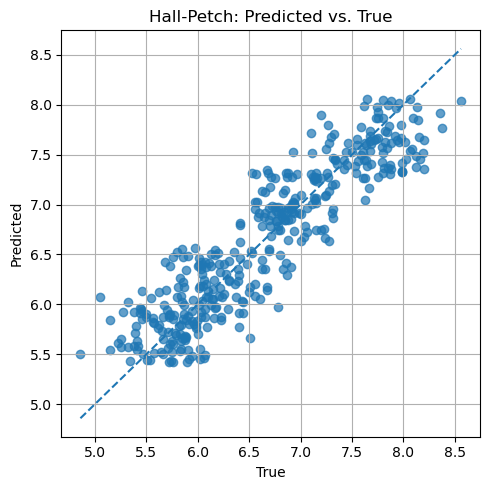

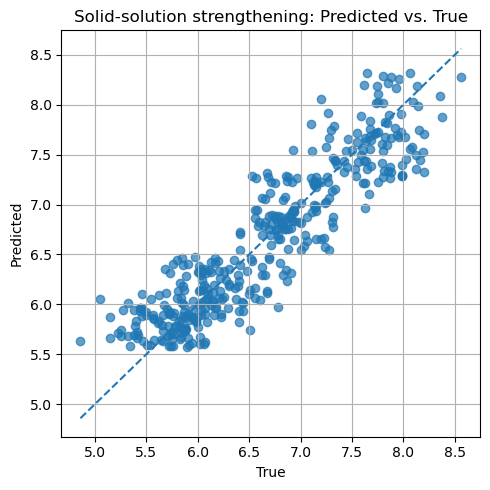

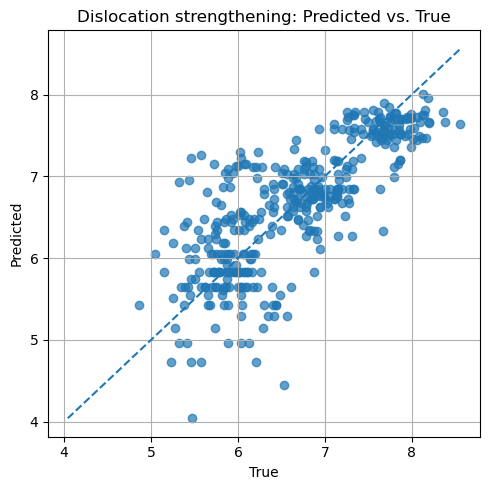

  - D:\\Research\\PtAu\\Manuscript\\20260322-Submitted_Nature\\PySR_results\\Dis_result\20260405_084458_98wLRA\hall_of_fame.csv


In [18]:
# ============================================================
# 5. Fit and evaluate the three strengthening models
# ============================================================
model_hp, y_hp_pred, metrics_hp = fit_and_evaluate_model(
    model_hp, X_hp, y_all, model_name="Hall-Petch"
)

model_sss, y_sss_pred, metrics_sss = fit_and_evaluate_model(
    model_sss, X_sss, y_all, model_name="Solid-solution strengthening"
)

model_dis, y_dis_pred, metrics_dis = fit_and_evaluate_model(
    model_dis, X_dis, y_all, model_name="Dislocation strengthening"
)

plot_pred_vs_true(y_all, y_hp_pred, model_name="Hall-Petch")
plot_pred_vs_true(y_all, y_sss_pred, model_name="Solid-solution strengthening")
plot_pred_vs_true(y_all, y_dis_pred, model_name="Dislocation strengthening")

c:\Users\quan.li\.conda\envs\pySuper\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 6.180e+05
Progress: 4270 / 31000 total iterations (13.774%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.157e-01  0.000e+00  y = x₀
3           1.157e-01  1.341e-06  y = x₀ * 1.0001
5           1.141e-01  6.658e-03  y = (x₀ + x₁) * 0.50004
7           9.912e-02  7.050e-02  y = (x₀ * 0.77199) - (x₂ * -0.22874)
9           9.582e-02  1.695e-02  y = (x₀ * (0.51755 - (x₂ * -0.040853))) - -1.3846
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 7.550e+05
Progress: 9749 / 31000 total iterations (31.448%)
═════════

[ Info: Final population:
[ Info: Results saved to:



Best expression of [Unified model]
complexity                                                      7
loss                                                     0.099121
equation                    (x0 * 0.7719922) - (x2 * -0.22874318)
score                                                    0.070498
sympy_format                      x0*0.7719922 - (-0.22874318)*x2
lambda_format    PySRFunction(X=>x0*0.7719922 - (-0.22874318)*x2)
Name: 3, dtype: object

[Unified model] Performance
R²  = 0.8521
MAE = 0.2488
MSE = 0.0991


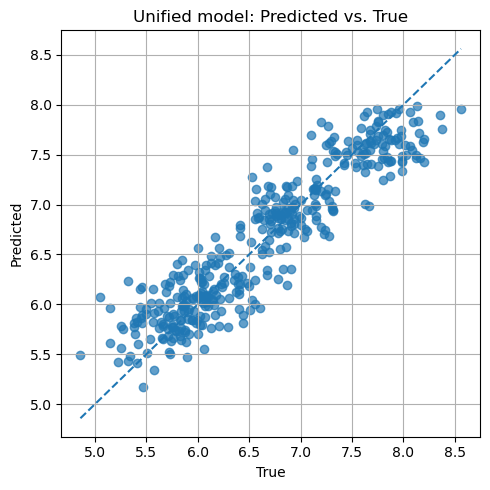

  - D:\\Research\\PtAu\\Manuscript\\20260322-Submitted_Nature\\PySR_results\\Unified_result\20260405_084742_H9bh5Y\hall_of_fame.csv


In [19]:
# ============================================================
# 6. Unified model using in-memory predictions
# ============================================================
# IMPORTANT:
# No need to save y_hp_pred/y_sss_pred/y_dis_pred to CSV and re-read them.
# Directly stack them in memory for the combined model.

X_unified = np.column_stack([y_hp_pred, y_sss_pred, y_dis_pred])
y_unified = y_all

model_unified = PySRRegressor(
    binary_operators=["+", "-", "*"],
    unary_operators=[],
    maxsize=10,
    niterations=1000,
    early_stop_condition="stop_if(loss, complexity) = loss < 0.01 && complexity < 50",
    model_selection="best",
    elementwise_loss="loss(x, y) = (x - y)^2",
    verbosity=3,
    procs=NPROCS,
    warm_start=True,
    output_directory=str(OUTPUT_ROOT / "Unified_result") if SAVE_RESULTS else None,
)

model_unified, y_unified_pred, metrics_unified = fit_and_evaluate_model(
    model_unified, X_unified, y_unified, model_name="Unified model"
)

plot_pred_vs_true(y_unified, y_unified_pred, model_name="Unified model")

In [20]:
# ============================================================
# 7. Collect results into one table
# ============================================================
results_df = pd.DataFrame({
    "Data No.": data_clean["Data No."].values,
    "hardness_true": y_all,
    "hardness_hp_pred": y_hp_pred,
    "hardness_sss_pred": y_sss_pred,
    "hardness_dis_pred": y_dis_pred,
    "hardness_unified_pred": y_unified_pred,
})

print("\nPreview of combined results table:")
print(results_df.head())


Preview of combined results table:
   Data No.  hardness_true  hardness_hp_pred  hardness_sss_pred  \
0         1          8.130          7.978580           8.187944   
1         2          7.990          7.325714           7.288779   
2         3          7.980          7.792318           7.907013   
3         4          7.990          7.415333           7.399078   
4         5          7.991          7.335421           7.300550   

   hardness_dis_pred  hardness_unified_pred  
0           8.011444               7.991964  
1           7.766838               7.432005  
2           7.582108               7.749965  
3           7.717445               7.489892  
4           7.717449               7.428202  


In [21]:

# ============================================================
# 8. Save outputs optionally
# ============================================================
if SAVE_RESULTS:
    ensure_output_dir(OUTPUT_ROOT)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save prediction table
    pred_path = OUTPUT_ROOT / f"SR_all_predictions_{timestamp}.csv"
    results_df.to_csv(pred_path, index=False)

    # Save metric summary
    metrics_df = pd.DataFrame([
        {"Model": "Hall-Petch", **metrics_hp},
        {"Model": "Solid-solution strengthening", **metrics_sss},
        {"Model": "Dislocation strengthening", **metrics_dis},
        {"Model": "Unified model", **metrics_unified},
    ])
    metrics_path = OUTPUT_ROOT / f"SR_metrics_summary_{timestamp}.csv"
    metrics_df.to_csv(metrics_path, index=False)

    # Save best expressions
    expr_path = OUTPUT_ROOT / f"SR_best_expressions_{timestamp}.txt"
    with open(expr_path, "w", encoding="utf-8") as f:
        f.write("[Hall-Petch]\n")
        f.write(str(model_hp.get_best()))
        f.write("\n\n[Solid-solution strengthening]\n")
        f.write(str(model_sss.get_best()))
        f.write("\n\n[Dislocation strengthening]\n")
        f.write(str(model_dis.get_best()))
        f.write("\n\n[Unified model]\n")
        f.write(str(model_unified.get_best()))

    print("\nSaved files:")
    print(pred_path)
    print(metrics_path)
    print(expr_path)

print("\nWorkflow completed successfully.")


Saved files:
D:\Research\PtAu\Manuscript\20260322-Submitted_Nature\PySR_results\SR_all_predictions_20260405_085009.csv
D:\Research\PtAu\Manuscript\20260322-Submitted_Nature\PySR_results\SR_metrics_summary_20260405_085009.csv
D:\Research\PtAu\Manuscript\20260322-Submitted_Nature\PySR_results\SR_best_expressions_20260405_085009.txt

Workflow completed successfully.
